In [65]:
import regex as re
import importlib
import tokenizer
importlib.reload(tokenizer)
st = tokenizer.SimpleTokenizer
import data_loader
importlib.reload(data_loader)
gt  = data_loader.GPTDataset
from torch.utils.data import DataLoader

In [66]:
with open("the-verdict.txt","r",encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of characters:",len(raw_text))
print(raw_text[:99])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [67]:
preprocessed_text = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed_text = [token.split()[0] for token in preprocessed_text if token.strip()]
print("Total number of tokens:",len(preprocessed_text))
print(preprocessed_text[:30])

Total number of tokens: 4690
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [68]:
ordered_list = sorted(set(preprocessed_text))
vocab_size = len(ordered_list)
print("Vocabulary size:",vocab_size)


Vocabulary size: 1130


In [69]:
vocab_dict = {token:idx for idx,token in enumerate(ordered_list)}
print("Vocabulary dictionary:",dict(list(vocab_dict.items())[:30]))

Vocabulary dictionary: {'!': 0, '"': 1, "'": 2, '(': 3, ')': 4, ',': 5, '--': 6, '.': 7, ':': 8, ';': 9, '?': 10, 'A': 11, 'Ah': 12, 'Among': 13, 'And': 14, 'Are': 15, 'Arrt': 16, 'As': 17, 'At': 18, 'Be': 19, 'Begin': 20, 'Burlington': 21, 'But': 22, 'By': 23, 'Carlo': 24, 'Chicago': 25, 'Claude': 26, 'Come': 27, 'Croft': 28, 'Destroyed': 29}


In [70]:
t = st(raw_text)
text = """"It's the last he painted, you know," Mrs. Gisburn said with pardonable pride."""
ids = t.encode(text)
print("Encoded ids:",ids)

Encoded ids: [1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [71]:
decoded_text = t.decode(ids)
print("Decoded text:",decoded_text)

Decoded text: " It's the last he painted, you know," Mrs. Gisburn said with pardonable pride.


In [72]:
text = "Hello, world! It' s a test."
ids = t.encode(text)
print("Encoded ids:",ids)

Encoded ids: [1134, 5, 1134, 0, 56, 2, 850, 115, 1134, 7]


In [73]:
text1 = "Hello, world! It's a test."
text2 = "Here is such a big palace that it can be used to store a lot of things."
text = "<|BOS|> " + text1 + " <|EOS|> " + text2 + " <|endoftext|>"
ids = t.encode(text)
print("Encoded ids:",ids)

Encoded ids: [1131, 1134, 5, 1134, 0, 56, 2, 850, 115, 1134, 7, 1133, 1134, 584, 949, 115, 219, 1134, 987, 585, 244, 198, 1057, 1016, 1134, 115, 1134, 722, 997, 7, 1130]


In [74]:
import tiktoken
print("tiktoken version:", importlib.metadata.version("tiktoken"))


tiktoken version: 0.13.0


In [75]:
tokenizer = tiktoken.get_encoding("gpt2")

In [76]:
text1 = "Hello, world! It's a test."
text2 = "Here is such a big palace that it can be used to store alotofthings."
text = " <|endoftext|> ".join([text1, text2])
ids = tokenizer.encode(text,allowed_special={"<|endoftext|>"})
print("Encoded ids:",ids)

Encoded ids: [15496, 11, 995, 0, 632, 338, 257, 1332, 13, 220, 50256, 3423, 318, 884, 257, 1263, 20562, 326, 340, 460, 307, 973, 284, 3650, 43158, 1659, 27971, 13]


In [77]:
text_decoded = tokenizer.decode(ids)
print("Decoded text:",text_decoded)

Decoded text: Hello, world! It's a test. <|endoftext|> Here is such a big palace that it can be used to store alotofthings.


In [78]:
enc_text = tokenizer.encode(raw_text)
len_enc_text = len(enc_text)
print("Length of encoded text:",len_enc_text)

Length of encoded text: 5145


In [79]:
enc_sample = enc_text[50:]

In [80]:
context_size = 4
input_array = enc_sample[:context_size]
output_array = enc_sample[1:context_size+1]
print("Input array:",input_array)
print("Output array:",output_array)

Input array: [290, 4920, 2241, 287]
Output array: [4920, 2241, 287, 257]


In [81]:
for i in range(context_size):
    context = input_array[:i+1]
    output = output_array[i]
    print(f"Context: {context}, Output: {output}")

Context: [290], Output: 4920
Context: [290, 4920], Output: 2241
Context: [290, 4920, 2241], Output: 287
Context: [290, 4920, 2241, 287], Output: 257


In [82]:
for i in range(context_size):
    context = enc_sample[:i+1]
    output = enc_sample[i+1]
    print(f"Context: {tokenizer.decode(context)}, Output: {tokenizer.decode([output])}")

Context:  and, Output:  established
Context:  and established, Output:  himself
Context:  and established himself, Output:  in
Context:  and established himself in, Output:  a


In [83]:
def create_data_loader(txt, batch_size=4, context_size=256,
                       stride=128,shuffle=True,drop_last=True,
                       cpu_thread_number=4):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = gt(txt, tokenizer, context_size, stride)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                             drop_last=drop_last, num_workers=cpu_thread_number)
    return data_loader


In [84]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [85]:
dataloader = create_data_loader(raw_text, batch_size=10, context_size=4, stride=1,
                                shuffle=False, drop_last=True, cpu_thread_number=4)
data_iter = iter(dataloader)
first_batch = next(data_iter)

In [86]:
print("First batch Input:", first_batch[0])
print("First batch Target:", first_batch[1])

First batch Input: tensor([[   40,   367,  2885,  1464],
        [  367,  2885,  1464,  1807],
        [ 2885,  1464,  1807,  3619],
        [ 1464,  1807,  3619,   402],
        [ 1807,  3619,   402,   271],
        [ 3619,   402,   271, 10899],
        [  402,   271, 10899,  2138],
        [  271, 10899,  2138,   257],
        [10899,  2138,   257,  7026],
        [ 2138,   257,  7026, 15632]])
First batch Target: tensor([[  367,  2885,  1464,  1807],
        [ 2885,  1464,  1807,  3619],
        [ 1464,  1807,  3619,   402],
        [ 1807,  3619,   402,   271],
        [ 3619,   402,   271, 10899],
        [  402,   271, 10899,  2138],
        [  271, 10899,  2138,   257],
        [10899,  2138,   257,  7026],
        [ 2138,   257,  7026, 15632],
        [  257,  7026, 15632,   438]])


In [87]:
import gensim.downloader as api
word_vectors = api.load("word2vec-google-news-300")

In [88]:
print(word_vectors['king'])

[ 1.25976562e-01  2.97851562e-02  8.60595703e-03  1.39648438e-01
 -2.56347656e-02 -3.61328125e-02  1.11816406e-01 -1.98242188e-01
  5.12695312e-02  3.63281250e-01 -2.42187500e-01 -3.02734375e-01
 -1.77734375e-01 -2.49023438e-02 -1.67968750e-01 -1.69921875e-01
  3.46679688e-02  5.21850586e-03  4.63867188e-02  1.28906250e-01
  1.36718750e-01  1.12792969e-01  5.95703125e-02  1.36718750e-01
  1.01074219e-01 -1.76757812e-01 -2.51953125e-01  5.98144531e-02
  3.41796875e-01 -3.11279297e-02  1.04492188e-01  6.17675781e-02
  1.24511719e-01  4.00390625e-01 -3.22265625e-01  8.39843750e-02
  3.90625000e-02  5.85937500e-03  7.03125000e-02  1.72851562e-01
  1.38671875e-01 -2.31445312e-01  2.83203125e-01  1.42578125e-01
  3.41796875e-01 -2.39257812e-02 -1.09863281e-01  3.32031250e-02
 -5.46875000e-02  1.53198242e-02 -1.62109375e-01  1.58203125e-01
 -2.59765625e-01  2.01416016e-02 -1.63085938e-01  1.35803223e-03
 -1.44531250e-01 -5.68847656e-02  4.29687500e-02 -2.46582031e-02
  1.85546875e-01  4.47265

In [89]:
print(word_vectors['queen'].shape)

(300,)


In [90]:
print(word_vectors.similarity('king', 'queen'))

0.6510957


In [91]:
print(word_vectors.most_similar(positive=['king','woman'], negative=['man'], topn=10))

[('queen', 0.7118193507194519), ('monarch', 0.6189674139022827), ('princess', 0.5902431011199951), ('crown_prince', 0.5499460697174072), ('prince', 0.5377321839332581), ('kings', 0.5236844420433044), ('Queen_Consort', 0.5235945582389832), ('queens', 0.518113374710083), ('sultan', 0.5098593235015869), ('monarchy', 0.5087411403656006)]


In [92]:
print(word_vectors.similarity('apple', 'man'))
print(word_vectors.similarity('apple', 'orange'))
print(word_vectors.similarity('apple', 'pear'))
print(word_vectors.similarity('apple', 'heaven'))
print(word_vectors.similarity('apple', 'Adam'))
print(word_vectors.similarity('apple', 'Eve'))
print(word_vectors.similarity('apple', 'Satan'))

0.11685415
0.39203462
0.64506966
0.11087046
0.13577957
0.25482452
0.13343525


In [93]:
input_ids = torch.tensor([2,3,5,1])

In [94]:
vocab_size = 6
vec_dim = 3
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, vec_dim)

In [95]:
print("Embedding layer weights:", embedding_layer.weight)

Embedding layer weights: Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [96]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [97]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [98]:
vocab_size = 50257
vec_dim = 256
embedding_layer = torch.nn.Embedding(vocab_size, vec_dim)

In [99]:
context_length = 4
dataloader = create_data_loader(raw_text, batch_size=8, context_size=context_length, stride=context_length,
                                shuffle=False)
data_iter = iter(dataloader)
first_batch_input,first_batch_target = next(data_iter)

In [100]:
print("Input Token IDs:\t",first_batch_input)
print("Input Shape:\t",first_batch_input.shape)

Input Token IDs:	 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Input Shape:	 torch.Size([8, 4])


In [101]:
token_embedding = embedding_layer(first_batch_input)
print("Token Embedding Shape:\t",token_embedding.shape)

Token Embedding Shape:	 torch.Size([8, 4, 256])


In [102]:
pos_embedding_layer = torch.nn.Embedding(context_length, vec_dim)
print("Positional Embedding Layer Size:\t",pos_embedding_layer.weight.shape)

Positional Embedding Layer Size:	 torch.Size([4, 256])


In [103]:
pos_embedding_vectors = pos_embedding_layer(torch.arange(context_length))
print("Positional Embedding Vectors Shape:\t",pos_embedding_vectors.shape)

Positional Embedding Vectors Shape:	 torch.Size([4, 256])


In [104]:
first_batch_input_with_pos = token_embedding + pos_embedding_vectors
print("First Batch Input with Positional Embedding Shape:\t",first_batch_input_with_pos.shape)

First Batch Input with Positional Embedding Shape:	 torch.Size([8, 4, 256])


In [105]:
import torch
input = torch.tensor([[0.43, 0.15, 0.89], [0.55, 0.87, 0.66], [0.57, 0.85, 0.64], [0.22, 0.58, 0.33], [0.77, 0.25, 0.10], [0.05, 0.80, 0.55]])

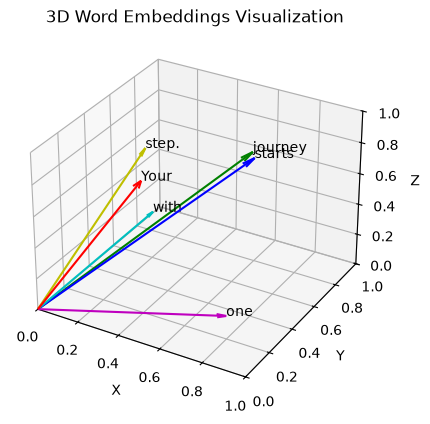

In [106]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
words = ['Your','journey','starts','with','one','step.']
x_cords = input[:,0].numpy()
y_cords = input[:,1].numpy()
z_cords = input[:,2].numpy()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for x, y, z, word, color in zip(x_cords, y_cords, z_cords, words, colors):
    ax.quiver(
        0, 0, 0,       # arrow origin
        x, y, z,       # direction/vector
        arrow_length_ratio=0.05,
        color=color,
    )
    ax.text(x, y, z, word,fontsize=10)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Word Embeddings Visualization')
plt.show()

In [107]:
attention_matrix = torch.empty(input.shape[0], input.shape[0])
for i,x_i in enumerate(input):
    input_i_attention_weight = torch.empty(input.shape[0])
    for j , x_j in enumerate(input):
        input_i_attention_weight[j] = torch.dot(x_i, x_j)
    print("Attention score vector ",i,":\n", input_i_attention_weight)
    attention_matrix[i] = input_i_attention_weight
print("Attention scores:\n", attention_matrix)

Attention score vector  0 :
 tensor([0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310])
Attention score vector  1 :
 tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention score vector  2 :
 tensor([0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605])
Attention score vector  3 :
 tensor([0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565])
Attention score vector  4 :
 tensor([0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935])
Attention score vector  5 :
 tensor([0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450])
Attention scores:
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [108]:
attention_weight_sum_normalized_matrix = torch.empty(input.shape[0], input.shape[0])
for i, x_i in enumerate(attention_matrix):
    x_i_sum = torch.sum(x_i)
    for j, x_i_j in enumerate(x_i):
        normalized_weight = x_i_j / x_i_sum
        attention_weight_sum_normalized_matrix[i, j] = normalized_weight

print("Normalized Attention weights:\n", attention_weight_sum_normalized_matrix)

Normalized Attention weights:
 tensor([[0.2241, 0.2140, 0.2113, 0.1066, 0.1026, 0.1415],
        [0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656],
        [0.1454, 0.2277, 0.2248, 0.1280, 0.1104, 0.1637],
        [0.1304, 0.2313, 0.2275, 0.1354, 0.0953, 0.1801],
        [0.1436, 0.2219, 0.2245, 0.1090, 0.2088, 0.0921],
        [0.1350, 0.2325, 0.2269, 0.1405, 0.0628, 0.2022]])


In [109]:
def naive_softmax(x):
    exp_x = torch.exp(x)
    sum_exp_x = torch.sum(exp_x)
    softmax_x = exp_x / sum_exp_x
    return softmax_x
attention_weight_softmax_naive_matrix = torch.empty(input.shape[0], input.shape[0])
for i, x_i in enumerate(attention_matrix):
    softmax_weights = naive_softmax(x_i)
    attention_weight_softmax_naive_matrix[i] = softmax_weights
print("Softmax Normalized Attention weights:\n", attention_weight_softmax_naive_matrix)

Softmax Normalized Attention weights:
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [110]:
attention_weight_softmax_matrix = torch.empty(input.shape[0], input.shape[0])
for i, x_i in enumerate(attention_matrix):
    attention_weight_softmax_matrix[i] = torch.softmax(x_i, dim=0)

print("Softmax Normalized Attention weights:\n", attention_weight_softmax_matrix)

Softmax Normalized Attention weights:
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [111]:
atten_scores = input @ input.T
print("Attention scores using matrix multiplication:\n", atten_scores)
print("atten scores == attention_matrix:", torch.allclose(atten_scores, attention_matrix))

Attention scores using matrix multiplication:
 tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
atten scores == attention_matrix: True


In [112]:
atten_weights = torch.softmax(atten_scores, dim=-1)
print("Softmax Normalized Attention weights using matrix multiplication:\n", atten_weights)
print("atten_weights == attention_weights:", torch.allclose(atten_weights, attention_weight_softmax_matrix))

Softmax Normalized Attention weights using matrix multiplication:
 tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
atten_weights == attention_weights: True


In [113]:
context_vec = atten_weights @ input
print("Context vectors:\n", context_vec)
print("Context vectors shape:\n", context_vec.shape)

Context vectors:
 tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
Context vectors shape:
 torch.Size([6, 3])


In [114]:
# x_2 = input[1]
d_in = input.shape[1]
d_out = 2

In [115]:
torch.manual_seed(123)
W_q = torch.nn.Parameter(torch.rand(d_in, d_out),requires_grad=False)
W_k = torch.nn.Parameter(torch.rand(d_in, d_out),requires_grad=False)
W_v = torch.nn.Parameter(torch.rand(d_in, d_out),requires_grad=False)

In [116]:
query = input @ W_q
key = input @ W_k
value = input @ W_v

In [117]:
atten_scores_trainable = query @ key.T

In [118]:
atten_weights_trainable = torch.softmax(atten_scores_trainable/(key.shape[-1]**0.5), dim=-1)
print("Trainable Softmax Normalized Attention weights:\n", atten_weights_trainable)
print(key.shape[-1])


Trainable Softmax Normalized Attention weights:
 tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])
2


In [119]:
context_vec_trainable = atten_weights_trainable @ value
print("Trainable Context vectors:\n", context_vec_trainable)

Trainable Context vectors:
 tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


In [120]:
import simple_attention
importlib.reload(simple_attention)
torch.manual_seed(123)
sa = simple_attention.SimpleAttention(d_in, d_out)

In [121]:
context_vec = sa.forward(input)
print("Context vectors from SimpleAttention class:\n", context_vec)

Softmax Normalized Attention weights:
 tensor([[0.1717, 0.1762, 0.1761, 0.1555, 0.1627, 0.1579],
        [0.1636, 0.1749, 0.1746, 0.1612, 0.1605, 0.1652],
        [0.1637, 0.1749, 0.1746, 0.1611, 0.1606, 0.1651],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.1632, 0.1674],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.1639],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)
Context vectors from SimpleAttention class:
 tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


In [122]:
keys = sa.W_k(input)
query = sa.W_q(input)
atten_scores = query @ keys.T
atten_weights = torch.softmax(atten_scores/(keys.shape[-1]**0.5), dim=-1)
print(atten_weights)

tensor([[0.1717, 0.1762, 0.1761, 0.1555, 0.1627, 0.1579],
        [0.1636, 0.1749, 0.1746, 0.1612, 0.1605, 0.1652],
        [0.1637, 0.1749, 0.1746, 0.1611, 0.1606, 0.1651],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.1632, 0.1674],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.1639],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)


In [123]:
contLen = atten_weights.shape[0]
mask_simple = torch.tril(torch.ones(contLen,contLen))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [124]:
masked_attention = atten_weights * mask_simple
print(masked_attention)

tensor([[0.1717, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1749, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1637, 0.1749, 0.1746, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.0000, 0.0000],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<MulBackward0>)


In [125]:
row_sums = masked_attention.sum(dim=1,keepdim=True)
masked_attention_normalized = masked_attention / row_sums
print(masked_attention_normalized)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<DivBackward0>)


In [126]:
mask = torch.triu(torch.ones(contLen,contLen),diagonal=1)
inifinity_masked = atten_scores.masked_fill(mask.bool(),-torch.inf)
print(inifinity_masked)

tensor([[0.3111,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1655, 0.2602,   -inf,   -inf,   -inf,   -inf],
        [0.1667, 0.2602, 0.2577,   -inf,   -inf,   -inf],
        [0.0510, 0.1080, 0.1064, 0.0643,   -inf,   -inf],
        [0.1415, 0.1875, 0.1863, 0.0987, 0.1121,   -inf],
        [0.0476, 0.1192, 0.1171, 0.0731, 0.0477, 0.0966]],
       grad_fn=<MaskedFillBackward0>)


In [127]:
atten_weights_inf = torch.softmax(inifinity_masked/keys.shape[-1]**0.5,dim=1)
print(atten_weights_inf)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)


In [128]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [133]:
print(dropout(atten_weights_inf))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.9665, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6380, 0.0000, 0.6804, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.5090, 0.5085, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4120, 0.4116, 0.3869, 0.3906, 0.0000],
        [0.0000, 0.3418, 0.3413, 0.3308, 0.0000, 0.3363]],
       grad_fn=<MulBackward0>)


In [138]:
batch = torch.stack((input,input),dim = 0)
print(batch)
print(batch.shape)

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])
torch.Size([2, 6, 3])


In [141]:
import causal_attention
importlib.reload(causal_attention)
torch.manual_seed(123)
context_length = batch.shape[1]
ca  = causal_attention.CausalAttention(d_in,d_out,context_length,0.0)
context_vecs = ca.forward(batch)
print(context_vecs.shape)

torch.Size([2, 6, 2])
